# Product Recognition on Store Shelves

**Exam Project:** Developed for the final exam by Massimo Modesti and Federico Tampieri as part of the course.  
This notebook implements a system for recognizing cereal box products on supermarket shelves, following the exam requirements.

---

# Step A - Multiple Product Detection
## 1. Setup and Configuration

In this section, we import necessary libraries, define directories for template and scene images, enumerate template IDs, set thresholds for matching and color filtering, and specify visualization parameters.

In [11]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Directories containing template (model) and scene (shelf) images
MODELS_DIR       = "./models/"    # contains files named 0.jpg, 1.jpg, ..., 26.jpg
SCENES_DIR       = './scenes/'    # contains files e1.png to e5.png

MODEL_IDS        = [0, 1, 11, 19, 24, 25, 26]
SCENE_FILES      = ["e1.png", "e2.png", "e3.png", "e4.png", "e5.png"]

# Models to be discriminated with color filter
CONFUSE_MODELS   = {1, 11, 0, 26}
HUE_DIFF_THRESH  = 17  # Allowed Hue difference (degrees)

# Matching and filtering parameters
MIN_MATCHES      = 30     # Minimum number of feature matches/inliers required for a valid detection
RATIO_TEST       = 0.7    # Lowe's ratio test parameter to filter ambiguous matches
MIN_AREA_RATIO   = 0.01   # Minimum bounding-box area ratio relative to scene size
RANSAC_THRESH    = 3.0    # RANSAC reprojection threshold (pixels)

# Visualization styles
BOX_COLOR    = (0, 255, 0)  # green box outlines
CENTER_COLOR = (0, 0, 255)  # red centers
TEXT_COLOR   = (0, 255, 0)  # green text
FONT         = cv2.FONT_HERSHEY_SIMPLEX
FONT_SCALE   = 0.7
TEXT_THICK   = 2
BOX_THICK    = 10
CIRCLE_RAD   = 4

Now, we add two functions:  
1. `def preprocess_scene(img_scene)`: Converts the image to LAB and applies CLAHE on the L (luminance) channel to boost local contrast without amplifying noise, then converts back to BGR—yielding clearer gradients and textures for more reliable feature detection;
2. `def calc_mean_hue(img_bgr)`: Converts the image to HSV and returns the average Hue (0–180 in OpenCV), providing a compact descriptor of the dominant color used later to disambiguate visually similar packages after geometric matching.

In [12]:
def preprocess_scene(img_scene): 
    lab = cv2.cvtColor(img_scene, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    lab = cv2.merge((cl, a, b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def calc_mean_hue(img_bgr): 
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    return float(np.mean(hsv[:, :, 0]))

Initialize SIFT and BFMatcher:

In [13]:
sift = cv2.SIFT_create()
bf   = cv2.BFMatcher(cv2.NORM_L2)

This block loads all reference models and prepares them for matching.
For each `MODEL_ID`, it reads the model image, computes SIFT keypoints and descriptors, records its size, and (for visually similar items listed in `CONFUSE_MODELS`) caches the model’s mean Hue for later color-based disambiguation.
All metadata are stored in the `models` dictionary, which serves as the lookup table used during scene detection.

In [14]:
# Model loading and preprocessing
models = {} 
for mid in MODEL_IDS: 
    path = os.path.join(MODELS_DIR, f"{mid}.jpg")
    img_model = cv2.imread(path)
    if img_model is None:
        raise FileNotFoundError(f"Model image not found: {path}")

    # keypoints and descriptors
    kp_model, des_model = sift.detectAndCompute(img_model, None)
    h_model, w_model = img_model.shape[:2]

    # mean hue for filtering models
    mean_hue = None
    if mid in CONFUSE_MODELS:
        mean_hue = calc_mean_hue(img_model)

    models[mid] = {
        'img': img_model,
        'kp': kp_model,
        'des': des_model,
        'size': (w_model, h_model),
        'mean_hue': mean_hue
    }

This block processes each shelf scene to **detect all occurrences of each reference product**.  
It extracts SIFT features, performs feature matching with each model, and verifies geometric consistency using **homography and RANSAC**, while applying **area and color filters** to refine the results.  
Finally, it **draws rotated bounding boxes and centroids** on the detected products and displays the final annotated scene.  


=== Analisi scena e1.png ===
Kp scena: 2630  Descriptors: (2630, 128)

[Model 0]: kp_model=8044  des_model=(8044, 128)
  Raw matches: 8044
  Good matches (ratio<0.7): 322
  Inliers RANSAC: 214
  Hue ROI=43.5, Model=48.0, Δ=4.5
  *** Detected model instance 0 (214 inliers) ***

[Model 1]: kp_model=3158  des_model=(3158, 128)
  Raw matches: 3158
  Good matches (ratio<0.7): 142
  Inliers RANSAC: 92
  Hue ROI=26.8, Model=57.7, Δ=30.9
  => Skip: color difference too high (>±17°)

[Model 11]: kp_model=1444  des_model=(1444, 128)
  Raw matches: 1444
  Good matches (ratio<0.7): 126
  Inliers RANSAC: 53
  Hue ROI=27.0, Model=25.7, Δ=1.2
  *** Detected model instance 11 (53 inliers) ***

[Model 19]: kp_model=1390  des_model=(1390, 128)
  Raw matches: 1390
  Good matches (ratio<0.7): 3
  => Skip: too few good matches (<30)

[Model 24]: kp_model=1083  des_model=(1083, 128)
  Raw matches: 1083
  Good matches (ratio<0.7): 14
  => Skip: too few good matches (<30)

[Model 25]: kp_model=2891  des_mode

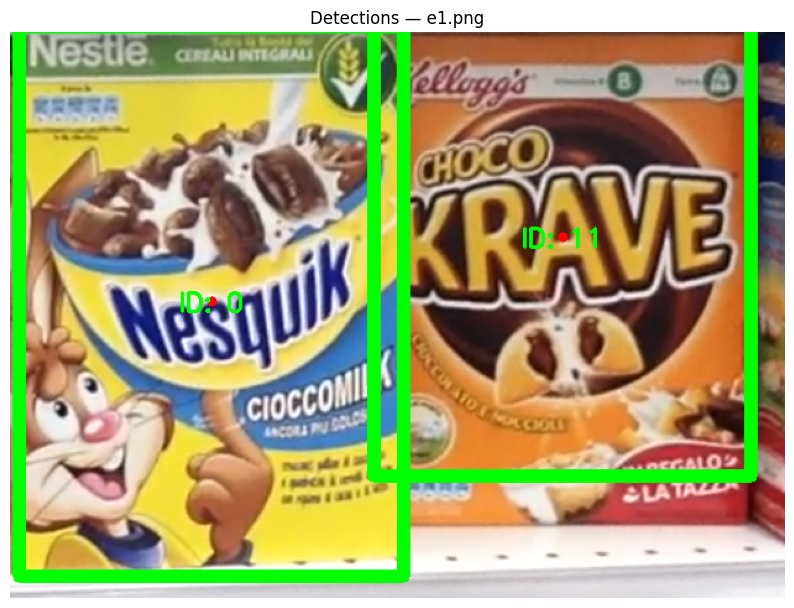


=== Analisi scena e2.png ===
Kp scena: 3434  Descriptors: (3434, 128)

[Model 0]: kp_model=8044  des_model=(8044, 128)
  Raw matches: 8044
  Good matches (ratio<0.7): 147
  Inliers RANSAC: 39
  Hue ROI=29.6, Model=48.0, Δ=18.4
  => Skip: color difference too high (>±17°)

[Model 1]: kp_model=3158  des_model=(3158, 128)
  Raw matches: 3158
  Good matches (ratio<0.7): 54
  Inliers RANSAC: 23
  => Skip: few inliers (<30)

[Model 11]: kp_model=1444  des_model=(1444, 128)
  Raw matches: 1444
  Good matches (ratio<0.7): 15
  => Skip: too few good matches (<30)

[Model 19]: kp_model=1390  des_model=(1390, 128)
  Raw matches: 1390
  Good matches (ratio<0.7): 5
  => Skip: too few good matches (<30)

[Model 24]: kp_model=1083  des_model=(1083, 128)
  Raw matches: 1083
  Good matches (ratio<0.7): 218
  Inliers RANSAC: 197
  *** Detected model instance 24 (197 inliers) ***

[Model 25]: kp_model=2891  des_model=(2891, 128)
  Raw matches: 2891
  Good matches (ratio<0.7): 198
  Inliers RANSAC: 119
 

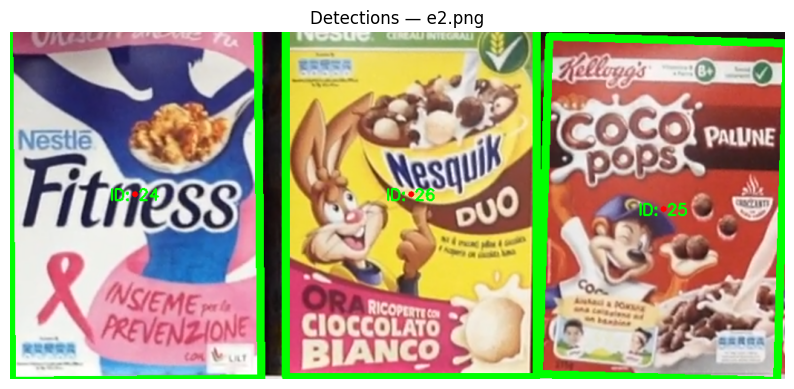


=== Analisi scena e3.png ===
Kp scena: 3454  Descriptors: (3454, 128)

[Model 0]: kp_model=8044  des_model=(8044, 128)
  Raw matches: 8044
  Good matches (ratio<0.7): 313
  Inliers RANSAC: 195
  Hue ROI=42.0, Model=48.0, Δ=6.1
  *** Detected model instance 0 (195 inliers) ***

[Model 1]: kp_model=3158  des_model=(3158, 128)
  Raw matches: 3158
  Good matches (ratio<0.7): 144
  Inliers RANSAC: 44
  Hue ROI=61.7, Model=57.7, Δ=4.0
  *** Detected model instance 1 (44 inliers) ***

[Model 11]: kp_model=1444  des_model=(1444, 128)
  Raw matches: 1444
  Good matches (ratio<0.7): 97
  Inliers RANSAC: 34
  Hue ROI=24.9, Model=25.7, Δ=0.8
  *** Detected model instance 11 (34 inliers) ***

[Model 19]: kp_model=1390  des_model=(1390, 128)
  Raw matches: 1390
  Good matches (ratio<0.7): 6
  => Skip: too few good matches (<30)

[Model 24]: kp_model=1083  des_model=(1083, 128)
  Raw matches: 1083
  Good matches (ratio<0.7): 7
  => Skip: too few good matches (<30)

[Model 25]: kp_model=2891  des_mod

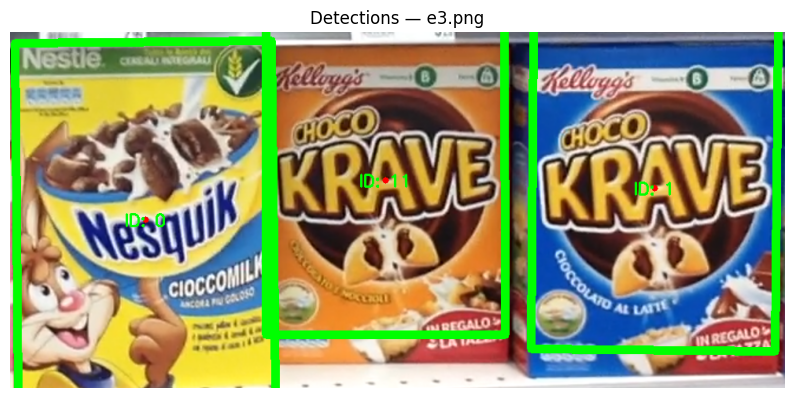


=== Analisi scena e4.png ===
Kp scena: 4710  Descriptors: (4710, 128)

[Model 0]: kp_model=8044  des_model=(8044, 128)
  Raw matches: 8044
  Good matches (ratio<0.7): 234
  Inliers RANSAC: 163
  Hue ROI=41.8, Model=48.0, Δ=6.2
  *** Detected model instance 0 (163 inliers) ***

[Model 1]: kp_model=3158  des_model=(3158, 128)
  Raw matches: 3158
  Good matches (ratio<0.7): 142
  Inliers RANSAC: 88
  Hue ROI=27.5, Model=57.7, Δ=30.1
  => Skip: color difference too high (>±17°)

[Model 11]: kp_model=1444  des_model=(1444, 128)
  Raw matches: 1444
  Good matches (ratio<0.7): 118
  Inliers RANSAC: 69
  Hue ROI=26.7, Model=25.7, Δ=1.0
  *** Detected model instance 11 (69 inliers) ***

[Model 19]: kp_model=1390  des_model=(1390, 128)
  Raw matches: 1390
  Good matches (ratio<0.7): 5
  => Skip: too few good matches (<30)

[Model 24]: kp_model=1083  des_model=(1083, 128)
  Raw matches: 1083
  Good matches (ratio<0.7): 10
  => Skip: too few good matches (<30)

[Model 25]: kp_model=2891  des_mode

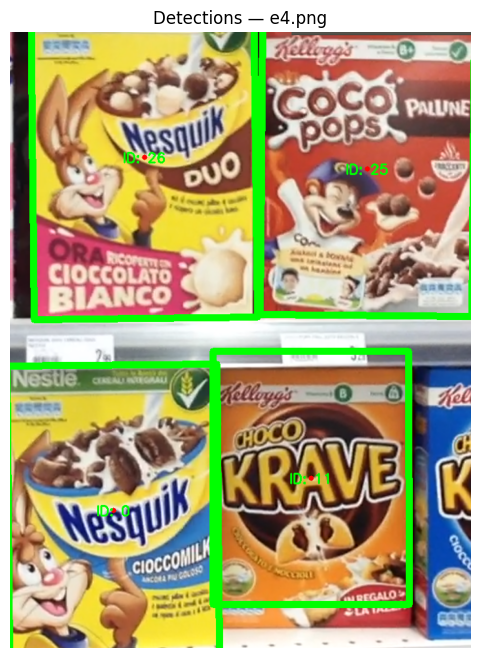


=== Analisi scena e5.png ===
Kp scena: 2468  Descriptors: (2468, 128)

[Model 0]: kp_model=8044  des_model=(8044, 128)
  Raw matches: 8044
  Good matches (ratio<0.7): 36
  Inliers RANSAC: 9
  => Skip: few inliers (<30)

[Model 1]: kp_model=3158  des_model=(3158, 128)
  Raw matches: 3158
  Good matches (ratio<0.7): 53
  Inliers RANSAC: 16
  => Skip: few inliers (<30)

[Model 11]: kp_model=1444  des_model=(1444, 128)
  Raw matches: 1444
  Good matches (ratio<0.7): 13
  => Skip: too few good matches (<30)

[Model 19]: kp_model=1390  des_model=(1390, 128)
  Raw matches: 1390
  Good matches (ratio<0.7): 174
  Inliers RANSAC: 143
  *** Detected model instance 19 (143 inliers) ***

[Model 24]: kp_model=1083  des_model=(1083, 128)
  Raw matches: 1083
  Good matches (ratio<0.7): 5
  => Skip: too few good matches (<30)

[Model 25]: kp_model=2891  des_model=(2891, 128)
  Raw matches: 2891
  Good matches (ratio<0.7): 178
  Inliers RANSAC: 94
  *** Detected model instance 25 (94 inliers) ***

[Mod

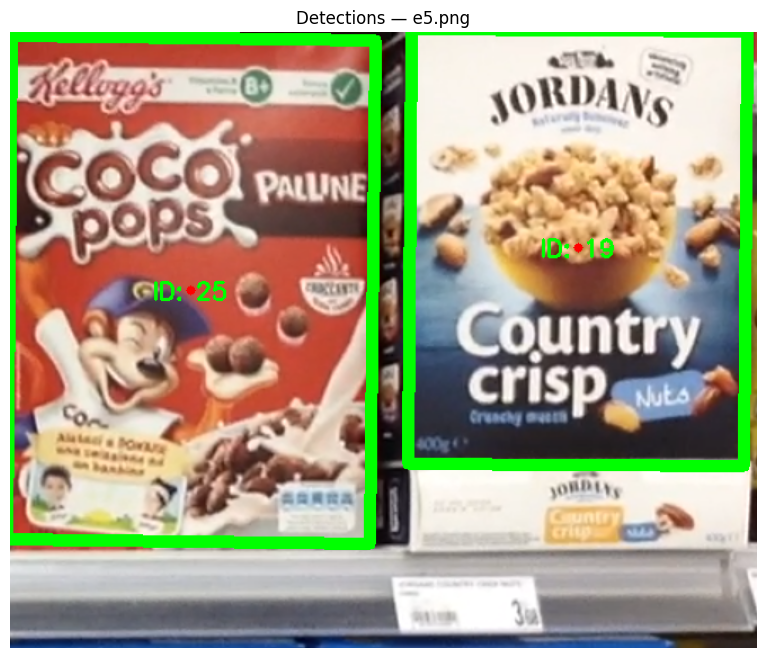

In [15]:
# Process each scene image
for scene_file in SCENE_FILES:
    # Load the scene image
    scene_path = os.path.join(SCENES_DIR, scene_file)
    img_scene = cv2.imread(scene_path)
    if img_scene is None:
        raise FileNotFoundError(f"Scene image not found: {scene_path}") 

    # Pre-process the scene (e.g. resizing, normalization)
    img_proc = preprocess_scene(img_scene)
    h_scene, w_scene = img_proc.shape[:2]

    # Extract SIFT keypoints and descriptors from the scene
    kp_scene, des_scene = sift.detectAndCompute(img_proc, None)
    print(f"\n=== Analisi scena {scene_file} ===")
    print(f"Kp scena: {len(kp_scene)}  Descriptors: {None if des_scene is None else des_scene.shape}")

    # Dictionary to store found detections (key: model_id, value: list of detections)
    detections = {} 
    
    # Loop through each model to search in the scene
    for mid, data in models.items(): 
        # Retrieve keypoints, descriptors and model dimensions
        kp_model = data['kp']
        des_model = data['des']
        w_model, h_model = data['size']

        print(f"\n[Model {mid}]: kp_model={len(kp_model)}  des_model={None if des_model is None else des_model.shape}")
        
        # Check that descriptors exist for both model and scene
        if des_model is None or des_scene is None:
            print("  => Skip: descriptors missing")
            continue

        # ========== 1) SIFT MATCHING + LOWE RATIO TEST ==========
        # Find the k=2 best matches for each model descriptor
        matches = bf.knnMatch(des_model, des_scene, k=2) 
        print(f"  Raw matches: {len(matches)}")
        
        # Apply Lowe's ratio test: keep only matches with distance significantly lower
        # than the second best match (reduces ambiguity)
        good = [m for m,n in matches if m.distance < RATIO_TEST * n.distance]
        print(f"  Good matches (ratio<{RATIO_TEST}): {len(good)}")
        
        # If good matches are too few, skip this model
        if len(good) < MIN_MATCHES:
            print(f"  => Skip: too few good matches (<{MIN_MATCHES})")
            continue

        # ========== 2) HOMOGRAPHY ESTIMATION WITH RANSAC ==========
        # Extract coordinates of corresponding keypoints
        # src_pts: points in model (query), dst_pts: points in scene (train)
        src_pts = np.float32([kp_model[m.queryIdx].pt for m in good]).reshape(-1,1,2)
        dst_pts = np.float32([kp_scene[m.trainIdx].pt for m in good]).reshape(-1,1,2)
        
        # Calculate homography matrix (perspective transformation) with RANSAC
        # RANSAC filters outliers for robust estimation
        M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, RANSAC_THRESH)
        
        if M is None:
            print("  => Skip: homography not found")
            continue
        
        # Count inliers (points that respect the transformation)
        inliers = int(mask.sum())
        print(f"  Inliers RANSAC: {inliers}")
        
        # If inliers are too few, the match is not reliable
        if inliers < MIN_MATCHES:
            print(f"  => Skip: few inliers (<{MIN_MATCHES})")
            continue

        # ========== 3) TRANSFORM MODEL CORNERS ==========
        # Define the 4 corners of the model (rectangle in model coordinates)
        corners = np.float32([[0,0],[w_model,0],[w_model,h_model],[0,h_model]]).reshape(-1,1,2)
        
        # Apply perspective transformation to find where they are projected in the scene
        dst_c  = cv2.perspectiveTransform(corners, M)
        pts    = dst_c.reshape(-1,2).astype(np.float32)

        # ========== 4) CALCULATE ROTATED BOUNDING BOX ==========
        # Calculate the minimum oriented rectangle enclosing the transformed points
        rot_rect = cv2.minAreaRect(pts)
        (cx, cy), (w_box, h_box), angle = rot_rect  # center, dimensions, rotation angle
        box_pts = cv2.boxPoints(rot_rect).astype(int)  # 4 vertices of rotated box

        # ========== 5) MINIMUM AREA FILTER ==========
        # Discard detections with area too small relative to the scene
        # (possible false positives or irrelevant detections)
        if w_box * h_box < MIN_AREA_RATIO * (w_scene * h_scene):
            print(f"  => Skip: area too small (<{MIN_AREA_RATIO*100:.2f}% scene)")
            continue

        # ========== 6) CONDITIONAL COLOR FILTER ==========
        # For easily confusable models (e.g. same design, different color)
        # verify mean color correspondence (hue in HSV)
        if mid in CONFUSE_MODELS:
            # Define source rectangle (model) and destination (scene)
            src_rect = np.float32([[0,0],[w_model,0],[w_model,h_model],[0,h_model]])
            dst_rect = np.float32(box_pts)
            
            # Calculate inverse transformation to extract ROI from scene
            M_inv    = cv2.getPerspectiveTransform(dst_rect, src_rect)
            roi      = cv2.warpPerspective(img_scene, M_inv, (w_model, h_model))
            
            # Calculate mean hue of ROI and compare with model hue
            mean_h_roi = calc_mean_hue(roi)
            diff_h     = abs(mean_h_roi - data['mean_hue'])
            print(f"  Hue ROI={mean_h_roi:.1f}, Model={data['mean_hue']:.1f}, Δ={diff_h:.1f}")
            
            # If color difference exceeds threshold, discard the detection
            if diff_h > HUE_DIFF_THRESH:
                print(f"  => Skip: color difference too high (>±{HUE_DIFF_THRESH}°)")
                continue

        # ========== VALID DETECTION - SAVE ==========
        # Store detection data for this model
        detections.setdefault(mid, []).append({
            'center': (int(round(cx)), int(round(cy))),  # bbox center
            'width':  int(round(w_box)),                  # width
            'height': int(round(h_box)),                  # height
            'angle':  angle,                              # rotation angle
            'box_pts': box_pts                            # 4 vertices of box
        })
        print(f"  *** Detected model instance {mid} ({inliers} inliers) ***")

    # ========== RESULTS REPORT ==========
    print(f"\nResults for {scene_file}:")
    if not detections:
        print("  No product recognized.")
    
    # Print details for each detected model
    for pid, dets in detections.items():
        print(f"  Model {pid} - {len(dets)} instance(s) found:")
        for idx, det in enumerate(dets, 1):
            cx, cy = det['center']
            w_b, h_b = det['width'], det['height']
            print(f"    Instance {idx} {{position: ({cx},{cy}), w={w_b}px, h={h_b}px, angle={det['angle']:.1f}°}}")

    # ========== VISUALIZATION ==========
    # Create copy of image to draw results
    vis = img_scene.copy()
    
    # Draw each detection
    for pid, dets in detections.items():
        for det in dets:
            # Draw the rotated bounding box
            cv2.drawContours(vis, [det['box_pts']], 0, BOX_COLOR, BOX_THICK)
            
            # Draw the centroid
            cv2.circle(vis, det['center'], CIRCLE_RAD, CENTER_COLOR, -1)
            
            # Add text with model ID, centered on detection
            text = f"ID: {pid}"
            (tw, th), _ = cv2.getTextSize(text, FONT, FONT_SCALE, TEXT_THICK)
            tx = det['center'][0] - tw // 2  # center horizontally
            ty = det['center'][1] + th // 2  # center vertically
            cv2.putText(vis, text, (tx, ty), FONT, FONT_SCALE, TEXT_COLOR, TEXT_THICK)

    # Display results with Matplotlib (for notebooks/IDEs)
    plt.figure(figsize=(10, 8))
    plt.title(f"Detections — {scene_file}")
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))  # Convert BGR -> RGB for correct colors
    plt.axis("off")
    plt.show()